# Notes

## Introduction to RAG
- RAG gives access to data on which models are not trained
- Answer questions: Collect information --- RETRIEVAL + Reason & respond --- GENERATION
    - Option1: No need to collect information --> Respond based on your knowledge
    - Option2: Extensive research --> synthesize research
- Prompt ->     LLM -> Great answer || Not so great answer -> 1. Very recent information 2. Specialized knowledge
                 |
            Internet data
- What LLMs don't know
    - Private databases
    - Hard to access information
    - Real time data

- **Retriever**
    - Manages knowledge base of trusted information
    - Finds the most relevant information and shares information with the LLM
    - Improves generation

- Application of RAGs : Company chatbots, code author, specialized knowledge, search engine as retrievers

## RAG Architecture Deep Dive
- Normal LLM : Prompt -> LLM -> Response
                Knowledge Base
                    ||
- RAG : Prompt -> Retriever > Relevant documents -> Augmented Prompt -> LLM -> Response

- Advantages of RAG
    - Injects missing knowledge
    - Reduces hallucinations
    - Keeps models upto date
    - Enables source citation
    - Focuses model on generation

## Token
- A piece of a word
- Some words get single tokens, compound words get multiple tokens
- ~10000-100000 tokens in LLMs vocabulary, allowing models to represent any possible word with fewer tokens
- Process current state ---> Calculate probabilities ---> Select next token
- LLM generates a probability distribution of the next token and then randomly chooses the next token from that probability distribution
- **Auto-regressive**
    - Self influencing
    - New tokens make sense in context of the old ones
    - Running the same prompt leads to different completion
## How LLMs learn

```
                      LLM
                       │
                       ▼
+--------------------------------------------------+
|                     TRAINING                     |
|                                                  |
|   Neural Network (billions of parameters)        |
|                                                  |
|   Input text with missing tokens                 |
|                                                  |
+--------------------------------------------------+
                       │
                       ▼
                 Predictions
                       │
                       ▼
                   Accurate?
                   /       \
                 No         Yes
                 │           │
                 ▼           ▼
        Update parameters   Continue
                 │
                 └───────────────→ repeat
```
### Why not train LLM on everything
- Higher computational cost
- Context window limit

### Hallucinations
- LLMs generate probable word sequences
- Knowledge gaps cause inaccurate responses
- Truthful != probable

## Retriever
- Share relevant information with LLM which was not available when the model was trained
- Prompt ---> Retriever ---> Knowledge base
- Retriever ranks the documents in the knowledge base basis the relevance to the prompt. Docs with the highest scores are returned
### Retriever tradeoffs
    - Relevance vs irrelevance:- Need to return relevant documents and withhold irrelevant ones
    - Return every document:- Wastes context window
    - Return the single highest ranked document:- Miss valuable information
    - No perfect solution: - Retriever usually doesn't perfectly rank documents
    - Monitor and experiment - Change settings to find what works

### Retriever Architecture
```
        +--------+
        | Prompt |
        +--------+
             │
             ▼
      +------------+          +----------------+
      | Retriever  |◄────────►| Knowledge Base |
      +------------+          +----------------+
             │
             ▼
   +--------------------+
   | Relevant Documents |
   +--------------------+
             │
             ▼
   +------------------+
   | Augmented Prompt |
   +------------------+
             │
             ▼
          +-----+
          | LLM |
          +-----+
             │
             ▼
       +----------+
       | Response |
       +----------+
```

#### Two Search Approaches
##### Keyword search
- Looks for documents containing the exact words found in the prompt
- Ensures sensitivity to exact words the user included in the prompt
- __Exact match__
###### Sparse Vectors
A sparse vector is generated for each document aka __Inverted Index__
- **Frequency based scoring** ---> **Normalized TF Scoring** ---> TF-IDF __(Inverse Document Frequency)__ ---> BM25 __(Best Matching 25)__
- **BM25**
    - Standard keyword search algorith in production retrievers
    - Better performance
    - Same cost
    - More flexibility
##### Semantic search
- Looks for documents with the similar meaning to the prompt
- Finds documents with similar meaning, even without matching words
- __Fuzzy match__
###### How does it work?
- Prompt and documents each get a vector
- Vectors are compared to generate scores
- The main difference between semantic search and keyword search is how the vectors are assigned
    - **Keyword search**: count words
    - **Semantic search**: use embedding model
        -  Embedding models map token to a location in space, this location is represented by a **vector**
        - Measure vector distance (cosine similarity, dot product)
        - **Higher values, closer vectors**
        - Rank by distance and the return the closest documents
###### Contrastive Training Process
 - Update internal parameters based on scoring the positive and negative pairs
    - Positive pairs - words with similar meaning
    - Negative pairs - words with different meaning
-  Repeat the process to improve the model : embed -> score with pairs -> Update parameters
- Model training
    - Beginning of training -> Random positions
    - Training -> Pushing and pulling
    - After training -> Meaningful embeddings


##### Metadata Filtering
- Narrows documents using rigid criteria
- It doesn't perform retrieval, but narrows down the results from other techniques
- Filters based on user attributes, not query content

#### Hybrid search
- Each search returns 20-50 documents. The ranking might differ from the two searches
- Each list filtered on document metadata to ensure only the relevant documents are filtered. **Metadata Filtering** excludes documents based on rigid criteria
- There are 2 filtered lists now, the lists are combined and the top ranked document is returned
    - Common algorithm for generating a combined rank **Reciprocal Rank Fusion**
        - Rewards documents for being highly ranked on each list
        - Control weight of keyword vs semantic ranking
        - It only cares about ranks, not the score of the document
- The document is added to the augmented prompt

### Retriever Quality Metrics
#### Precision
- Measures how many of the returned documents are relevant
- `Relevant retrieved/ total retrieved`
- Penalizes the retriever for  **returning irrelevant documents**
#### Recall
- Measures how many of the relevant documents are returned
- `Relevant retrieved/ total relevant`
Penalizes the retriever for  **leaving out relevant documents**
- recall@K is the most cited metric
- Captures the fundamental goal of finding relevant documents

#### Mean Average Precision
**MAP@K** evaluates average precision for relevant documents in the first K documents. It is built off a related metric called **average precision**
Higher metric is better

#### Reciprocal rank
- Measures the rank of the first relevant documents in the returned list

## Vector databases
- They are optimized for huge quantities of vector data
- Almost synonymous with RAG systems
- It is designed for __vector search__
    - Designed to store high dimensional vectors and perform vector search using ANN algorithms
- It outperforms relational databases
- Optimized for ANN Search
    - Designed to build HNSW indexes and compute vector distances
    - They scale well and operate quickly

### Basic vector retrieval - KNN
- `k`-nearest neighbour search
- What happens
    - **Vectorize** all documents and prompt
    - **Compute** distances to all document vectors
    - **Sort** by distance
    - **Return** closest elements
- Scale is a problem : __Linear Growth__
- To overcome, **Approximate Nearest Neighbors** (ANN)

### ANN (Approximate Nearest Neighbors)
- Significantly faster than KNN
- Rely on additional data structures
- Not guaranteed to find the absolute closest documents; though they will still find very closeby documents

#### Navigable small world
- Algo creates a data structure called **Proximity Graph**
    - Compute distances between each document vectors
    - Add one node to the graph for each document
    - Make an edge between each documents and a few of the other documents it is closest to
    - A __web like structure__ is created
- How does a proximity graph speeds up the search?
    - Prompt ---> vectorized ---> create a query vector
    - Find the documents located closest to that query vector
    - The algo randomly chooses an entry point --- __candidate vector__
    - The algo traverses the graph, finds the closest vector to the Query vector, whichever is the closest becomes the new __candidate__ --- REPEATS
    - Repeats until, no candidate is found which is closest to the query vector

#### Hierarchical Navigable Small World (HNSW)
- Enhances Navigable Small World by speeding up each parts of the search
- Relies on a hierarchical proximity graph
- How does it work?
    - **Layer1** : Contains all 1000 vectors with complete proximity graph
    - **Layer2** : Randomly drops to 100 vectors and build a new proximity graph for intermediate navigation
    - **Layer3** : Randomly drops to just 10 vectors and create a proximity graph for fast navigation at the highest level
    - **Searches begin in layer3**

## Chunking
It is a practice of breaking longer text documents from your knowledge base into smaller text chunks.
### Why chunk documents
1. Token limits of embedding models
2. Improved relevancy
3. LLM only sent relevant context
## Balancing chunk size
- Too big -> same issue as to go without chunking
- Too small -> Lost context, reduced search relevance
### Fixed size chunking
1. Overlapping chunking - include -x and +x in each chunk for overlapping
2. Recursive character splitting - splitting text into chunks at a specified character. Variable chunk size but better account for document structure
### Context aware chunking
- Costly pre-processing
- Good 1st improvement to explore

## Query parsing
### Query rewriting
- Use an LLM to rewrite the query before it's submitted to the retriever
### Named entity recognition
- Identifies and categorizes specific types of information within queries, enabling more targeted search and filtering strategies
- **GLINER** - Model for named entity recognition
### Hypothetical Document Embeddings (HyDE)
- Uses generated "hypothetical documents" that would be ideal search results to help with the search process
- Performance improvements but added latency

## Bi-Encoder
- Separate sematic vectors
- ANN search
- Documents vectors are pre computed
- __Reasonably good quality, great speed, minimal storage, default semantic search__

## Cross-Encoder
- Concatenate document and prompt
- Feed to cross encoder
- Generate relevance score
- __Best quality, extremely slow, minimal storage__

## ColBERT (Contextualized Late Interaction Over BERT)
- Split the difference between bi and cross encoders
- Each token gets a vector
- ColBERT scoring
- __Nearly the quality of a cross encoder, decent speed, significant vector storage__

## Reranking
- Post retrieval process
- Initial results before LLM regeneration are reranked
- Costly models
- Cross encoder models
- LLM based scoring

## LLM
### Transformer Architecture
### Origins of the transformer
- 2017 : Attention to detail
- Encoder
    - Processes the original text
    - Develops deep contextual understanding of text's meaning
    - Used in embedding models for rich semantic representations
- Decoder
    - Uses the deep understanding from the encoder
    - Generates new text in target language
    - Most LLMs only include the decoder component, as they just care about text generation
- **Iterative Refinement**
### Why RAG works?
    - LLMs can deeply understand information added to prompts through
            - Attention mechanism processing
            - World knowledge in feed forward layers
    - Inherent randomness remains
        - LLMs may randomly ignore injected information
        - Need to control randomness
        - Must confirm LLM grounds answers in retrieved information
    - Computational expense
        - Generating single tokens require extensive processing
        - Costs grow with prompt/ completion length
        - Each token must examine all others for context
        - Most RAG system costs come from running transformers
### LLM sampling strategies
#### Greedy decoding
- Sampling strategy that always selects the token with the highest probability at each step of text generation
- Makes LLM deterministic
- Generic sounding text (issue)
- Can get stuck in a loop -- doesn't care whether the output is meaningful
- Useful in code completion or debugging
##### Temperature
- Parameter that changes the shape of the distribution generated by the LLM. Directly related to randomness
- temp==- : Greedy decoding. High temperature---flat distribution
#### Advance token sampling
##### Top-K
- Picks only from the k most likely tokens, ignoring the rest
- Top-k always includes the same number of tokens regardless of the shape of the distribution
##### Top-P
- Picks from tokens whose cumulative probability is below some threshold
- It is more dynamic than top-k
- It includes more or fewer tokens depending on how "certain" the model is

#### Token specific strategies
##### Repetition penalties
Reduce the probability of already used tokens, discouraging repetition
##### Logit bias
- Direct manipulation of token probabilities

### Prompt engineering
#### Prompt Template
1. System instructions ```[system_prompt] # behavioral guidance```
2. Conversation history (if exists)```
User: {message_1}
Assistant: {response_1}
User: {message_2}
Assistant: {response_2}```
3. Retrieved information ```[DOCUMENT 1]
{chunk_1_text}
Source: {chunk_1_source}```
4. Current query

#### In context learning
1. One shot prompt
2. Two shot prompt
3. Few shot prompt

#### Encourage reasoning
- Tell the LLM to **think aloud** about how to approach the problem before providing a final answer

#### Chain of thought
Input -> Generate steps -> Follow steps -> Output

#### Reasoning models
- Reasoning tokens boost accuracy but add cost
- These models are slower & expensive
- Worth it in RAG for better relevance & integration
- Many prompting techniques don't work well on reasoning models

### Hallucinations
#### Why LLMs hallucinate
- LLMs produce probable text sequences
- Probable text is not always accurate, LLMs can't tell the difference

### Why hallucinations matter
- Inaccurate information
- Hard to detect
- Erode trust
- RAG can help

### Type of hallucinations
- Sometimes mess up small details
- Entirely invented facts
- Need to evaluate LLM output on many levels to ensure accuracy

### Detect hallucinations
#### Self-consistency methods
- Repeatedly generate responses to the same prompt and confirm consistency
- Factual inconsistencies can indicate hallucinations
- In practice, costly and unreliable

#### Reducing hallucinations with RAG
##### Citation generation
- Instruct LLM to cite sources after each sentence or paragraph
- Increases likelihood of grounding and makes human verification easier
- LLMs can just hallucinate citations
###### ContextCite
- Attributes sentences in response to retrieved documents
- Tags sentences with support document
- Can be used to generate citations or as part of evaluation

###### Evaluate citation quality in LLMs
1. ALCE Benchmark
   1. Key evaluation metrics
      1. Fluency
      2. Correctness
      3. Citation quality

### LLM metrics evaluation
- Retriever: Fetch documents || LLM: construct response
- LLM evals usually use other LLMs e.g. those found in the RAGAS library (open source). Metrics provided by it
    - Response relevancy
        - Not a check of factual correctness but the relevance
    - Faithfulness
        - %age of supported claims in the response
    - noise sensitivity, citations etc

### Agentic RAG
- Use several LLMs in your RAG system
- Each LLM is responsible for a single step

#### How it works
Complex task -> Broken into multiple steps -> Each completed by a call to a different LLM (Planning LLM | Research LLM | Writing LLM) -> LLMs are given access to external tools like code interpreter, internet and vector DB in case of RAG

#### Agentic system as flowcharts
- Each LLM completes one specific task in the prompts journey
- Different LLMs for different tasks
#### Types
- Sequential workflow (linear)
- Conditional workflow
    - Router
- Iterative workflow
    - Multiple response generation iterations based on an LLM evaluation
- Parallel workflow
    - Orchestrator splits the prompt and assign it to different LLMs
    - Synthesizer combines the different tasks to generate the response

### RAG vs fine tuning
#### Fine-tuning
- Retrain an LLM with your own data to update its internal parameters
- Done through supervised fine-tuning **SFT**
    - SFT retains the model with labeled examples
    - Instructions tuning teaches task-following behavior
        1. Feed instructions
        2. Compare output to correct answers
        3. Adjust internal parameters
- Fine-tuning does not teach new facts well. It mostly changes how a model talks, not what it knows

#### Comparison
| RAG                                       | Fine Tuning                       |
|-------------------------------------------|-----------------------------------|
| Best for knowledge injection              | Best for domain adaption          |
| Model can use the context from the prompt | Ideal for one clear, focused task |

#### Fine tune for RAG
- Train models specifically to incorporate retrieved information into responses
- RAG provides current, accurate information
- Fine-tuning optimizes how models use that information

## Real world applications


# Python refresher

In [14]:
import httpx

# Lists
l1 = ['RAG', 'is', 'awesome']
print(f"Original list: {l1}")

l1.append('!')
print(f"List after adding: {l1}")

l1.remove('awesome')
print(f"List after removing: {l1}")

result = l1.append("this is a test")
print(result)

squares = [x**2 for x in range(1,10)]
print(f"Sqaures: {squares}")

even_squares = [x**2 for x in range (1,10) if x%2==0]
print(even_squares)

person = {
    'name': 'Alice',
    'age': 22,
    'city': 'New York'
}
print(f"Person: {person}")
person['email'] = 'alice@wonderland.com'
print(f"Updated person: {person}")

for key, value in person.items():
    print(f"Key: {key}, value: {value}")

for val in person:
    print(val)

name = "John"
age = 30
greeting = f"Hello, {name}. You are {age} years old."
print(greeting)

people = [
    {
        "name": "Alice Johnson",
        "age": 28,
        "email": "alice.johnson@example.com",
        "location": "New York, NY"
    },
    {
        "name": "Michael Smith",
        "age": 34,
        "email": "michael.smith@example.com",
        "location": "Los Angeles, CA"
    },
    {
        "name": "Emily Davis",
        "age": 22,
        "email": "emily.davis@example.com",
        "location": "Austin, TX"
    },
    {
        "name": "John Brown",
        "age": 45,
        "email": "john.brown@example.com",
        "location": "Chicago, IL"
    },
    {
        "name": "Sarah Wilson",
        "age": 31,
        "email": "sarah.wilson@example.com",
        "location": "Seattle, WA"
    }
]
# Expected output
# ```
# Name: Alice Johnson, Age: 28, E-mail: alice.johnson@example.com, Location: New York, NY
# Name: Michael Smith, Age: 34, E-mail: michael.smith@example.com, Location: Los Angeles, CA
# ... (continues)
# ```

print("---------------------------------------------------------")
for person in people:
    output = f"Name: {person['name']}, Age: {person['age']}, Email: {person['email']}, Location: {person['location']}"
    print(output)
print("---------------------------------------------------------")

Original list: ['RAG', 'is', 'awesome']
List after adding: ['RAG', 'is', 'awesome', '!']
List after removing: ['RAG', 'is', '!']
None
Sqaures: [1, 4, 9, 16, 25, 36, 49, 64, 81]
[4, 16, 36, 64]
Person: {'name': 'Alice', 'age': 22, 'city': 'New York'}
Updated person: {'name': 'Alice', 'age': 22, 'city': 'New York', 'email': 'alice@wonderland.com'}
Key: name, value: Alice
Key: age, value: 22
Key: city, value: New York
Key: email, value: alice@wonderland.com
name
age
city
email
Hello, John. You are 30 years old.
---------------------------------------------------------
Name: Alice Johnson, Age: 28, Email: alice.johnson@example.com, Location: New York, NY
Name: Michael Smith, Age: 34, Email: michael.smith@example.com, Location: Los Angeles, CA
Name: Emily Davis, Age: 22, Email: emily.davis@example.com, Location: Austin, TX
Name: John Brown, Age: 45, Email: john.brown@example.com, Location: Chicago, IL
Name: Sarah Wilson, Age: 31, Email: sarah.wilson@example.com, Location: Seattle, WA
------

# LLM Calls & Crafting Simple Augmented Prompts

## Generate with single input
This function allows to generate text from a language model based on a single input prompt

In [21]:
from utils.utils_openAI import generate_with_single_input
from dotenv import load_dotenv

load_dotenv()

output = generate_with_single_input(prompt = "What is the capital of France?")
print ("Role: ", output['role'])
print ("Content: ", output['content'])

Role:  assistant
Content:  The capital of France is Paris.


## Generate with multiple input
This function is designed to handle multiple input messages in a conversational context. The input format is a dictionary with two keys:

1. 'role' - the role that the message is being passed (usually assistant, system or user)
2. 'content' - the prompt

In [22]:
from utils.utils_openAI import generate_with_multiple_input
from dotenv import load_dotenv

load_dotenv()
messages = [
    {'role': 'user', 'content': 'Hello, who won the FIFA world cup in 2018?'},
    {'role': 'assistant', 'content': 'France won the 2018 FIFA World Cup.'},
    {'role': 'user', 'content': 'Who was the captain?'}
]
output = generate_with_multiple_input(
    messages=messages,
    max_tokens=100
)
print("Role: ", output['role'])
print("Content: ", output['content'])

Role:  assistant
Content:  The captain of the French team that won the 2018 FIFA World Cup was Hugo Lloris.


## Integration of data into an LLM prompt

### Data

In [23]:
house_data = [
    {
        "address": "123 Maple Street",
        "city": "Springfield",
        "state": "IL",
        "zip": "62701",
        "bedrooms": 3,
        "bathrooms": 2,
        "square_feet": 1500,
        "price": 230000,
        "year_built": 1998
    },
    {
        "address": "456 Elm Avenue",
        "city": "Shelbyville",
        "state": "TN",
        "zip": "37160",
        "bedrooms": 4,
        "bathrooms": 3,
        "square_feet": 2500,
        "price": 320000,
        "year_built": 2005
    }
]

### Create the prompt

In [24]:
def house_info_layout(houses):
    layout = ''
    for house in houses:
        layout += (f"House located at {house['address']}, {house['city']}, {house['state']} {house['zip']} with "
                   f"{house['bedrooms']} bedrooms, {house['bathrooms']} bathrooms, "
                   f"{house['square_feet']} sq feet area, priced at ${house['price']}, "
                   f"built in {house['year_built']}.\n"
                   )
    return layout

In [25]:
print(house_info_layout(house_data))

House located at 123 Maple Street, Springfield, IL 62701 with 3 bedrooms, 2 bathrooms, 1500 sq feet area, priced at $230000, built in 1998.
House located at 456 Elm Avenue, Shelbyville, TN 37160 with 4 bedrooms, 3 bathrooms, 2500 sq feet area, priced at $320000, built in 2005.



In [26]:
def generate_prompt(query, houses):
    houses_layout = house_info_layout(houses)
    prompt = f"""
User the following houses information to answer user queries.
{houses_layout}
Query: {query}
"""
    return prompt

In [27]:
print(generate_prompt("Which is the most expensive house", house_data))


User the following houses information to answer user queries.
House located at 123 Maple Street, Springfield, IL 62701 with 3 bedrooms, 2 bathrooms, 1500 sq feet area, priced at $230000, built in 1998.
House located at 456 Elm Avenue, Shelbyville, TN 37160 with 4 bedrooms, 3 bathrooms, 2500 sq feet area, priced at $320000, built in 2005.

Query: Which is the most expensive house



In [29]:
query = "Which is the most expensive house? And the biggest one?"
query_without_house_info = generate_with_single_input(prompt = query, role='user')
print(query_without_house_info)
enhanced_query = generate_prompt(query, house_data)
query_with_house_info = generate_with_single_input(prompt = enhanced_query, role='assistant')

print(query_without_house_info['content'])
print("------------------------------------------------")
print(query_with_house_info['content'])

{'role': 'assistant', 'content': 'Could you please clarify which location or context you are referring to when you ask about the most expensive and biggest house? For example, are you asking about the most expensive and biggest house worldwide, in a specific country or city, or something else? This will help me provide the most accurate and relevant information.'}
Could you please clarify which location or context you are referring to when you ask about the most expensive and biggest house? For example, are you asking about the most expensive and biggest house worldwide, in a specific country or city, or something else? This will help me provide the most accurate and relevant information.
------------------------------------------------
The most expensive house is the one located at 456 Elm Avenue, Shelbyville, TN 37160, priced at $320,000. It is also the biggest house, with an area of 2,500 square feet.


# Vectors Embeddings in RAG

## Uses of vector embeddings
1. Powering search
   1. Capturing meaning
      1. Vector embeddings act like a map of text
      2. Convert words and sentences into positions in vector space that capture meaning
      3. These vectors can then be used to location information matching a query
   2. Comparing similarity
      1. Calculate similarity between the prompt's vector and other vectors in the DB to identify text closest in meaning to the prompt
2. Understanding context

## Framework for retrieval
1. Create the embedding
2. Metric measurement
   1. cosine similarity: closeness of two vectors based on their angle
   2. euclidean distance: straight line distance between two vectors in the embedding space
3. Sorting of documents by their similarity score

In [8]:
import numpy as np
import os
from utils.vector_utils import (
    display_widget,
    plot_vectors
)

In [5]:
def cosine_similarity(v1, array_of_vectors):
    """
    Compute the cosine similarity between a vector and an array of vectors.

    Parameters:
    v1 (array-like): The first vector.
    array_of_vectors (array-like): An array of vectors or a single vector.

    Returns:
    list: A list of cosine similarities between v1 and each vector in array_of_vectors.
    """
    # Ensure that v1 is a numpy array
    v1 = np.array(v1)
    # Initialize a list to store similarities
    similarities = []

    # Check if array_of_vectors is a single vector
    if len(np.shape(array_of_vectors)) == 1:
        array_of_vectors = [array_of_vectors]

    # Iterate over each vector in the array
    for v2 in array_of_vectors:
        # Convert the current vector to a numpy array
        v2 = np.array(v2)
        # Compute the dot product of v1 and v2
        dot_product = np.dot(v1, v2)
        # Compute the norms of the vectors
        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)
        # Compute the cosine similarity and append to the list
        similarity = dot_product / (norm_v1 * norm_v2)
        similarities.append(similarity)
    return [float(x) for x in similarities]

def euclidean_distance(v1, array_of_vectors):
    """
    Compute the Euclidean distance between a vector and an array of vectors.

    Parameters:
    v1 (array-like): The first vector.
    array_of_vectors (array-like): An array of vectors or a single vector.

    Returns:
    list: A list of Euclidean distances between v1 and each vector in array_of_vectors.
    """
    # Ensure that v1 is a numpy array
    v1 = np.array(v1)
    # Initialize a list to store distances
    distances = []

    # Check if array_of_vectors is a single vector
    if len(np.shape(array_of_vectors)) == 1:
        array_of_vectors = [array_of_vectors]

    # Iterate over each vector in the array
    for v2 in array_of_vectors:
        # Convert the current vector to a numpy array
        v2 = np.array(v2)
        # Check if the input arrays have the same shape
        if v1.shape != v2.shape:
            raise ValueError(f"Shapes don't match: v1 shape: {v1.shape}, v2 shape: {v2.shape}")
        # Calculate the Euclidean distance and append to the list
        dist = np.sqrt(np.sum((v1 - v2) ** 2))
        distances.append(dist)
    return [float(x) for x in distances]

In [32]:
# Example
v1 = [1, 2]
v2 = [1, 1]
array_v = [[3, 2], [5, 6]]
cosine_v1_v2 = cosine_similarity(v1, v2)
cosine_v1_array_v = cosine_similarity(v1, array_v)
euclidean_v1_v2 = euclidean_distance(v1, v2)
euclidean_v1_array_v = euclidean_distance(v1, array_v)
print(f"Cosine Similarity between v1 and v2: {cosine_v1_v2}")
print(f"Cosine Similarities between v1 and array_v: {cosine_v1_array_v}")
print(f"Euclidean Distance between v1 and v2: {euclidean_v1_v2}")
print(f"Euclidean Distances between v1 and array_v: {euclidean_v1_array_v}")

Cosine Similarity between v1 and v2: [0.9486832980505138]
Cosine Similarities between v1 and array_v: [0.8682431421244593, 0.973417168333576]
Euclidean Distance between v1 and v2: [1.0]
Euclidean Distances between v1 and array_v: [2.0, 5.656854249492381]


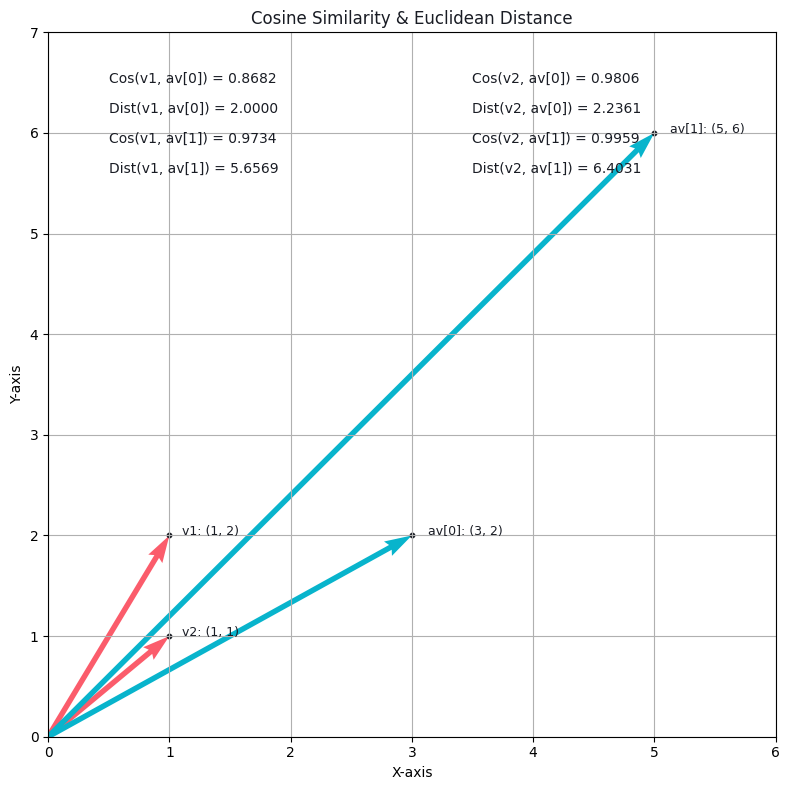

In [33]:
plot_vectors()

# The embedding model

In [1]:
import os
from sentence_transformers import SentenceTransformer

# Load the pre-trained sentence transformer model
model_name =  "BAAI/bge-base-en-v1.5"
model = SentenceTransformer(model_name)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
# To get a string embedded, just pass it to the model.
res = model.encode("RAG is awesome")
print(res.shape)

(768,)


In [10]:
words = ['apple', 'car', 'fruit', 'automobile', 'love', 'sentiment']
vectorized_words = model.encode(words)
word = 'apple'
print(f"{word}:")
for i, w in enumerate(words):
    # Get the vectorized word for the word defined above
    vectorized_word = vectorized_words[words.index(word)]
    print(f"\t{w}:\t\tCosine Similarity: {cosine_similarity(vectorized_word, vectorized_words[i])[0]:.4f}")
print("\n")
for i, w in enumerate(words):
    # Get the vectorized word for the word defined above
    vectorized_word = vectorized_words[words.index(word)]
    print(f"\t{w}:\t\tEuclidean Distance: {euclidean_distance(vectorized_word, vectorized_words[i])[0]:.4f}")

apple:
	apple:		Cosine Similarity: 1.0000
	car:		Cosine Similarity: 0.7446
	fruit:		Cosine Similarity: 0.4677
	automobile:		Cosine Similarity: 0.4330
	love:		Cosine Similarity: 0.6919
	sentiment:		Cosine Similarity: 0.7905


	apple:		Euclidean Distance: 0.0000
	car:		Euclidean Distance: 0.7147
	fruit:		Euclidean Distance: 1.0318
	automobile:		Euclidean Distance: 1.0649
	love:		Euclidean Distance: 0.7850
	sentiment:		Euclidean Distance: 0.6472


In [11]:
def retrieve_relevant(query, documents, metric='cosine_similarity'):
    """
    Retrieves and ranks documents based on their similarity to a given query using the specified metric.

    Parameters:
    query (str): The query string for which relevant documents are to be retrieved.
    documents (list of str): A list of documents to be compared against the query.
    metric (str, optional): The similarity measurement metric to be used. It supports 'cosine_similarity'
                            and 'euclidean'. Defaults to 'cosine_similarity'.

    Returns:
    list of tuples: A list of tuples where each tuple contains a document and its similarity or distance
                    score with respect to the query. The list is sorted based on these scores, with
                    descending order for 'cosine_similarity' and ascending order for 'euclidean'.
    """
    query_emb = model.encode(query)
    documents_emb = model.encode(documents)
    vals = []

    if metric == 'cosine_similarity':
        distances = cosine_similarity(query_emb, documents_emb)
        vals = [(doc, dist) for doc, dist in zip(documents, distances)]
        # Sort in descending order
        vals.sort(reverse=True, key=lambda x: x[1])

    elif metric == 'euclidean':
        distances = euclidean_distance(query_emb, documents_emb)
        vals = [(doc, dist) for doc, dist in zip(documents, distances)]
        # Sort in ascending order
        vals.sort(key=lambda x: x[1])

    return vals

In [12]:
documents = [
    "Mt. Fuji is a breathtaking place to explore during autumn.",
    "Santorini offers stunning views to admire during spring.",
    "Banff National Park is a picturesque destination to visit in the summer.",
    "The Great Wall of China is a spectacular site to experience during winter.",
    "The fjords of Norway are a magical place to cruise through in the spring.",
    "Prague is an enchanting city to wander through in winter.",
    "Kyoto's cherry blossoms create a beautiful scene to witness during spring.",
    "Marrakech offers vibrant markets and culture to enjoy in the fall.",
    "The Maldives are a paradisiacal getaway to savor during summer.",
    "The Christmas markets in Vienna are a festive delight to explore in winter."
]

query = "Suggest to me great places to visit in Asia."
score = retrieve_relevant(query, documents, metric='cosine_similarity')
score

[('The Great Wall of China is a spectacular site to experience during winter.',
  0.6080513000488281),
 ('Mt. Fuji is a breathtaking place to explore during autumn.',
  0.5821483135223389),
 ('The Maldives are a paradisiacal getaway to savor during summer.',
  0.5604640245437622),
 ('Santorini offers stunning views to admire during spring.',
  0.5512208938598633),
 ('Banff National Park is a picturesque destination to visit in the summer.',
  0.5220361948013306),
 ("Kyoto's cherry blossoms create a beautiful scene to witness during spring.",
  0.5150057077407837),
 ('The fjords of Norway are a magical place to cruise through in the spring.',
  0.48470237851142883),
 ('The Christmas markets in Vienna are a festive delight to explore in winter.',
  0.4710908830165863),
 ('Marrakech offers vibrant markets and culture to enjoy in the fall.',
  0.4674411416053772),
 ('Prague is an enchanting city to wander through in winter.',
  0.44837164878845215)]

In [13]:
score = retrieve_relevant(query, documents, metric='euclidean')
score

[('The Great Wall of China is a spectacular site to experience during winter.',
  0.8853798508644104),
 ('Mt. Fuji is a breathtaking place to explore during autumn.',
  0.9141681790351868),
 ('The Maldives are a paradisiacal getaway to savor during summer.',
  0.9375883936882019),
 ('Santorini offers stunning views to admire during spring.',
  0.9473955035209656),
 ('Banff National Park is a picturesque destination to visit in the summer.',
  0.9777156114578247),
 ("Kyoto's cherry blossoms create a beautiful scene to witness during spring.",
  0.9848800301551819),
 ('The fjords of Norway are a magical place to cruise through in the spring.',
  1.015182375907898),
 ('The Christmas markets in Vienna are a festive delight to explore in winter.',
  1.0285028219223022),
 ('Marrakech offers vibrant markets and culture to enjoy in the fall.',
  1.0320454835891724),
 ('Prague is an enchanting city to wander through in winter.',
  1.0503603219985962)]

In [14]:
display_widget(model)

# Retrieval Metrics

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

import ssl
import certifi

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())


## Load the dataset

In [2]:
from sklearn.datasets import fetch_20newsgroups

# Load the 20 Newsgroups dataset
newsgroups_train = fetch_20newsgroups(subset='train', shuffle=True, random_state=42, data_home='./dataset')

# Convert the dataset to a DataFrame for easier handling
df = pd.DataFrame({
    'text': newsgroups_train.data,
    'category': newsgroups_train.target
})

# Display some basic information about the dataset
print(df.head())
print("\nDataset Size:", df.shape)
print("\nNumber of Categories:", len(newsgroups_train.target_names))
print("\nCategories:", newsgroups_train.target_names)

                                                text  category
0  From: lerxst@wam.umd.edu (where's my thing)\nS...         7
1  From: guykuo@carson.u.washington.edu (Guy Kuo)...         4
2  From: twillis@ec.ecn.purdue.edu (Thomas E Will...         4
3  From: jgreen@amber (Joe Green)\nSubject: Re: W...         1
4  From: jcm@head-cfa.harvard.edu (Jonathan McDow...        14

Dataset Size: (11314, 2)

Number of Categories: 20

Categories: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [3]:
print(f"TEXT:\n\t{df['text'][0]}\nCATEGORY:\n\t{newsgroups_train.target_names[df['category'][0]]}")

TEXT:
	From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----





CATEGORY:
	rec.autos


## Preprocessing and vectorizing data

In [7]:
model_name =  "BAAI/bge-base-en-v1.5"
model = SentenceTransformer(model_name)

embedding_vectors = joblib.load('embeddings.joblib')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
len(embedding_vectors)

11314

## Basic functions for retrieval

In [9]:
def preprocess_text(text):
    """
    Preprocess the text data by removing leading and trailing whitespace.

    Parameters:
    text (str): The input text to preprocess.

    Returns:
    str: The preprocessed text, with leading and trailing whitespace removed.
    """
    # Example preprocessing: remove leading/trailing whitespace
    text = text.strip()
    return text


def cosine_similarity(v1, array_of_vectors):
    """
    Cosine similarity between a vector and either a single vector (1D) or an array of vectors (2D).
    Returns a float for 1D input, or a list of floats for 2D input.
    Safely handles PyTorch tensors (moves to CPU) and NumPy arrays.
    """
    # Handle torch tensors for v1
    if hasattr(v1, "detach"):  # torch tensor
        v1 = v1.detach().cpu().numpy()
    v1 = np.asarray(v1, dtype=np.float32).ravel()

    # Handle torch tensors for array_of_vectors
    if hasattr(array_of_vectors, "detach"):  # torch tensor
        array_of_vectors = array_of_vectors.detach().cpu().numpy()
    A = np.asarray(array_of_vectors, dtype=np.float32)

    if A.ndim == 1:
        A = A.ravel()
        denom = np.linalg.norm(v1) * np.linalg.norm(A)
        return float(0.0 if denom == 0 else np.dot(v1, A) / denom)

    # 2D case: compute similarities for each row in A
    A = np.atleast_2d(A)
    v1_norm = np.linalg.norm(v1)
    A_norms = np.linalg.norm(A, axis=1)
    denom = v1_norm * A_norms
    with np.errstate(divide='ignore', invalid='ignore'):
        sims = (A @ v1) / np.where(denom == 0, 1.0, denom)
    sims[denom == 0] = 0.0
    return sims.tolist()


def top_k_greatest_indices(lst, k):
    """
    Get the indices of the top k greatest items in a list.

    Parameters:
    lst (list): The list of elements to evaluate.
    k (int): The number of top elements to retrieve by index.

    Returns:
    list: A list of indices corresponding to the top k greatest elements in lst.
    """
    # Enumerate the list to keep track of indices
    indexed_list = list(enumerate(lst))
    # Sort by element values in descending order
    sorted_by_value = sorted(indexed_list, key=lambda x: x[1], reverse=True)
    # Extract the top k indices
    top_k_indices = [index for index, value in sorted_by_value[:k]]
    return top_k_indices

In [10]:
def retrieve_documents(query, embeddings, model, top_k=5):
    """
    Retrieve top-k most similar documents to a query using cosine similarity.
    Assumes:
      - preprocess_text, top_k_greatest_indices, df, and newsgroups_train are defined elsewhere.
      - embeddings is an iterable of document embeddings (NumPy arrays or torch tensors).
      - model.encode supports convert_to_tensor parameter (e.g., sentence-transformers).
    """

    query_clean = preprocess_text(query)
    query_embedding = model.encode(query_clean, convert_to_tensor=False).astype(np.float32)

    cosine_scores = []
    for x in embeddings:
        # Ensure each embedding is a NumPy array
        if hasattr(x, "detach"):  # torch tensor
            x = x.detach().cpu().numpy()
        x = np.asarray(x, dtype=np.float32)

        score = cosine_similarity(query_embedding, x)  # returns a float for 1D x
        cosine_scores.append(float(score))

    top_results = top_k_greatest_indices(cosine_scores, k=top_k)

    print(f"Query: {query}")
    for idx in top_results:
        print(f"Document: {df.iloc[idx]['text'][:200]}...")
        print(f"Category: {newsgroups_train.target_names[df.iloc[idx]['category']]}...")
        print("\n\n")


# Example query
example_query = "space exploration"
retrieve_documents(example_query, embedding_vectors, model, top_k = 2)

Query: space exploration
Document: From: u1452@penelope.sdsc.edu (Jeff Bytof - SIO)
Subject: End of the Space Age?
Organization: San Diego Supercomputer Center @ UCSD
Lines: 16
Distribution: world
NNTP-Posting-Host: penelope.sdsc.edu

...
Category: sci.space...



Document: From: dennisn@ecs.comm.mot.com (Dennis Newkirk)
Subject: Space class for teachers near Chicago
Organization: Motorola
Distribution: usa
Nntp-Posting-Host: 145.1.146.43
Lines: 59

I am posting this for...
Category: sci.space...





## Precision@K

In [12]:
def precision_at_k(relevant_count, k):
    """
    Calculate the Precision@K for a retrieval system.

    Precision@K is the ratio of relevant documents in the top K retrieved documents
    to the total number K of documents retrieved.

    Args:
        relevant_count (int): Number of relevant documents in the top K results.
        k (int): Total number of documents retrieved (K).

    Returns:
        float: The Precision@K value, or 0.0 if k is zero.

    Raises:
        ValueError: If any input is negative.
    """
    if relevant_count < 0 or k < 0:
        raise ValueError("All input values must be non-negative.")

    if k == 0:
        return 0.0

    return relevant_count / k

## Recall@K

In [13]:
def recall_at_k(relevant_count, total_relevant):
    """
    Calculate the Recall@K for a retrieval system.

    Recall@K is the ratio of relevant documents in the top K retrieved documents
    to the total number of relevant documents in the entire corpus.

    Args:
        relevant_count (int): Number of relevant documents in the top K results.
        total_relevant (int): Total number of relevant documents in the corpus.

    Returns:
        float: The Recall@K value, or 0.0 if total_relevant is zero.

    Raises:
        ValueError: If any input is negative.
    """
    if relevant_count < 0 or total_relevant < 0:
        raise ValueError("All input values must be non-negative.")

    if total_relevant == 0:
        return 0.0

    return relevant_count / total_relevant

In [14]:
test_queries = [
    {"query": "advancements in space exploration technology", "desired_category": "sci.space"},
    {"query": "real-time rendering techniques in computer graphics", "desired_category": "comp.graphics"},
    {"query": "latest findings in cardiovascular medical research", "desired_category": "sci.med"},
    {"query": "NHL playoffs and team performance statistics", "desired_category": "rec.sport.hockey"},
    {"query": "impacts of cryptography in online security", "desired_category": "sci.crypt"},
    {"query": "the role of electronics in modern computing devices", "desired_category": "sci.electronics"},
    {"query": "motorcycles maintenance tips for enthusiasts", "desired_category": "rec.motorcycles"},
    {"query": "high-performance baseball tactics for championships", "desired_category": "rec.sport.baseball"},
    {"query": "historical influence of politics on society", "desired_category": "talk.politics.misc"},
    {"query": "latest technology trends in the Windows operating system", "desired_category": "comp.os.ms-windows.misc"}

]

In [15]:
def compute_metrics(queries, embeddings, model, top_k=5):
    """
    Compute Precision@K and Recall@K for a list of queries against a dataset of document embeddings.
    Assumes:
      - preprocess_text, top_k_greatest_indices, precision_at_k, recall_at_k, df, newsgroups_train are defined elsewhere.
      - embeddings is a list/iterable of document embeddings (NumPy arrays or torch tensors).
      - model.encode supports convert_to_tensor parameter (e.g., sentence-transformers).
    """

    results = []

    # Normalize all embeddings to NumPy once
    np_embeddings = []
    for x in embeddings:
        if hasattr(x, "detach"):  # torch tensor
            x = x.detach().cpu().numpy()
        np_embeddings.append(np.asarray(x, dtype=np.float32).ravel())
    E = np.vstack(np_embeddings)  # shape: (N, D)

    for item in queries:
        query = item["query"]
        desired_category = item["desired_category"]

        # Get NumPy, not torch, to avoid GPU->NumPy conversion errors
        q_clean = preprocess_text(query)
        q_emb = model.encode(q_clean, convert_to_tensor=False)
        q_emb = np.asarray(q_emb, dtype=np.float32).ravel()

        # Compute similarities vectorized
        cosine_scores = cosine_similarity(q_emb, E)  # list of floats length N

        # Top-K indices
        top_results = top_k_greatest_indices(cosine_scores, k=top_k)

        # Retrieved categories
        retrieved_categories = [
            newsgroups_train.target_names[df.iloc[idx]["category"]] for idx in top_results
        ]

        # Metrics
        relevant_in_top_k = sum(1 for cat in retrieved_categories if cat == desired_category)
        total_relevant_in_corpus = sum(
            1 for idx in range(len(df))
            if newsgroups_train.target_names[df.iloc[idx]["category"]] == desired_category
        )

        p = precision_at_k(relevant_in_top_k, top_k)
        r = recall_at_k(relevant_in_top_k, total_relevant_in_corpus)

        results.append({
            "query": query,
            "precision@k": p,
            "recall@k": r,
        })

    return results

In [16]:
# Run the queries and compute metrics with different K values
k_values = [5, 20, 50]

for k in k_values:
    print(f"\n{'='*80}")
    print(f"Results with K={k}:")
    print('='*80)
    results = compute_metrics(test_queries, embedding_vectors, model, top_k=k)

    # Display the results
    for result in results:
        print(f"Query: {result['query']}")
        print(f"  Precision@{k}: {result['precision@k']:.2f}, Recall@{k}: {result['recall@k']:.2f}")
        print()


Results with K=5:
Query: advancements in space exploration technology
  Precision@5: 1.00, Recall@5: 0.01

Query: real-time rendering techniques in computer graphics
  Precision@5: 1.00, Recall@5: 0.01

Query: latest findings in cardiovascular medical research
  Precision@5: 1.00, Recall@5: 0.01

Query: NHL playoffs and team performance statistics
  Precision@5: 1.00, Recall@5: 0.01

Query: impacts of cryptography in online security
  Precision@5: 1.00, Recall@5: 0.01

Query: the role of electronics in modern computing devices
  Precision@5: 1.00, Recall@5: 0.01

Query: motorcycles maintenance tips for enthusiasts
  Precision@5: 1.00, Recall@5: 0.01

Query: high-performance baseball tactics for championships
  Precision@5: 1.00, Recall@5: 0.01

Query: historical influence of politics on society
  Precision@5: 0.40, Recall@5: 0.00

Query: latest technology trends in the Windows operating system
  Precision@5: 0.80, Recall@5: 0.01


Results with K=20:
Query: advancements in space explor

# Vector DB

In [4]:
from weaviate.classes.config import Configure, Property, DataType
from weaviate.classes.query import Filter
from typing import List
from tqdm import tqdm
import joblib
import weaviate
import re
from weaviate.util import generate_uuid5
from pprint import pprint
import os

In [3]:
from utils.weavite_utils import (
    suppress_subprocess_output,
    generate_with_single_input,
    print_object_properties,
    kill_processes_on_ports
)

import app.flask_app as flask_app

<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


 * Serving Flask app 'app.flask_app'
 * Debug mode: off


Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.
On macOS, try disabling the 'AirPlay Receiver' service from System Preferences -> General -> AirDrop & Handoff.


In [8]:
import certifi
import ssl
def create_ssl_context():
    return ssl.create_default_context(cafile=certifi.where())

ssl._create_default_https_context = create_ssl_context

In [10]:
import weaviate
client = weaviate.connect_to_embedded(
    version="1.28.2",
    headers={
        "X-OpenAI-Api-Key": os.getenv("OPENAI_API_KEY"),
    },
)

{"build_git_commit":"5a3991d2d4","build_go_version":"go1.23.4","build_image_tag":"HEAD","build_wv_version":"1.28.2","level":"warning","log_level_env":"","msg":"log level not recognized, defaulting to info","time":"2026-04-12T00:08:46+05:30"}
{"action":"startup","build_git_commit":"5a3991d2d4","build_go_version":"go1.23.4","build_image_tag":"HEAD","build_wv_version":"1.28.2","default_vectorizer_module":"none","level":"info","msg":"the default vectorizer modules is set to \"none\", as a result all new schema classes without an explicit vectorizer setting, will use this vectorizer","time":"2026-04-12T00:08:46+05:30"}
{"action":"startup","auto_schema_enabled":true,"build_git_commit":"5a3991d2d4","build_go_version":"go1.23.4","build_image_tag":"HEAD","build_wv_version":"1.28.2","level":"info","msg":"auto schema enabled setting is set to \"true\"","time":"2026-04-12T00:08:46+05:30"}
{"build_git_commit":"5a3991d2d4","build_go_version":"go1.23.4","build_image_tag":"HEAD","build_wv_version":"1.

In [16]:
data = joblib.load("dataset/data.joblib")
print_object_properties(data[0])

place: Grand Canyon
state: Arizona
description: A stunning canyon with vast vistas and incredible geology.
best_season_to_visit: Spring, Fall
attractions: South Rim, Havasu Falls, Skywalk
budget: Moderate
user_ratings: 4.8
last_updated: 2023-10-01T00:00:00Z



In [17]:
vectorizer_config = [Configure.NamedVectors.text2vec_transformers(
                name="vector", # This is the name you will need to access the vectors of the objects in your collection
                source_properties=['place', 'state', 'description', 'best_season_to_visit', 'attractions', 'budget'], # which properties should be used to generate a vector, they will be appended to each other when vectorizing
                vectorize_collection_name = False, # This tells the client to not vectorize the collection name.
                                                   # If True, it will be appended at the beginning of the text to be vectorized
                inference_url="http://127.0.0.1:5000", # Since we are using an API based vectorizer, you need to pass the URL used to make the calls
                                                       # This was setup in our Flask application
            )]

In [18]:
if client.collections.exists("example_collectiom"):
    client.collections.delete("example_collection")


In [20]:
if not client.collections.exists('example_collection'): # Creates only if the collection does not exist
    collection = client.collections.create(
            name='example_collection',
            vectorizer_config=vectorizer_config, # The config we defined before,
            reranker_config=Configure.Reranker.transformers(), # The reranker config

            properties=[  # Define properties
            Property(name="place",vectorize_property_name=True,data_type= DataType.TEXT),
            Property(name="state",vectorize_property_name=True, data_type=DataType.TEXT),
            Property(name="description",vectorize_property_name=True, data_type=DataType.TEXT),
            Property(name="best_season_to_visit",vectorize_property_name=True, data_type=DataType.TEXT),
            Property(name="attractions",vectorize_property_name=True, data_type=DataType.TEXT),
            Property(name="budget",vectorize_property_name=True, data_type=DataType.TEXT),
            Property(name="user_ratings", data_type=DataType.NUMBER),
            Property(name="last_updated", data_type=DataType.DATE),

        ]
        )
else:
    collection = client.collections.get("example_collection")

UnexpectedStatusCodeError: Collection may not have been created properly.! Unexpected status code: 422, with response body: {'error': [{'message': 'target vector "vector": vectorizer: no module with name "text2vec-transformers" present'}]}.

# Chunking

# LLM

In [1]:
import json
import random
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from utils.utils_openAI import (
    generate_with_single_input,
    generate_with_multiple_input
)

In [3]:
def generate_params_dict(
        prompt: str,
        temperature: float = None,
        role = 'user',
        top_p: float = None,
        max_tokens: int = 500,
        model: str = "gpt-4.1-mini",
):
        return {"prompt": prompt, "role": role, "temperature": temperature, "top_p": top_p, "max_tokens": max_tokens, "model": model}

In [4]:
kwargs = generate_params_dict("solve 2x+1=0.")
print(kwargs)

{'prompt': 'solve 2x+1=0.', 'role': 'user', 'temperature': None, 'top_p': None, 'max_tokens': 500, 'model': 'gpt-4.1-mini'}


In [ ]:
result = generate_with_single_input(**kwargs)
print(result['content'])

{
  "model": "gpt-4.1-mini",
  "input": [
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "solve 2x+1=0."
        }
      ]
    }
  ],
  "max_output_tokens": 500
}
